[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cca-cce/osm-comm/blob/main/jnb/skod52_example.ipynb)


# 1. Introduction

Motivate your CCA project by situating the problem in sustainability communication. Summarize key theoretical concepts and prior findings that inform your approach. State a clear purpose and formulate focused research questions and/or hypotheses that can be operationalized with a small, well-defined corpus.


Understanding how energy companies communicate sustainability is essential for analyzing how they justify their strategic decisions and maintain legitimacy in the face of environmental scrutiny. As a major actor in the global energy sector, **Equinor** uses its public website to present narratives about climate action, renewable investments, technological innovation, and responsibility within ongoing fossil-fuel operations. These texts are central to how the company frames its transition strategy and positions itself in relation to key stakeholders such as governments, communities, and investors.

This notebook reports a small-scale **computational content analysis (CCA)** of ten sustainability-related webpages from Equinor’s public website, converted to PDF and processed using NLP techniques (NER, POS tagging, aspect-based lexical analysis, concordances, and word-cloud visualizations). The goal is to demonstrate a transparent, replicable workflow for analyzing how corporate sustainability narratives are linguistically constructed.

### Potential Theoretical Approaches

Because these steps are not tied to any single theoretical framework, they allow investigation of multiple perspectives, such as:

* **Framing theory**: through aspect analysis, noun phrases, modal verbs
* **Legitimacy theory**: through stakeholder mentions, action verbs, future-oriented vs. present-oriented language
* **Stakeholder theory**: via NER-based actor salience
* **CSR/ESG theory**: via the Environmental–Social–Governance segmentation
* **Mediatization/strategic communication**: via modality, appeals, narrative form
* **Organizational identity**: recurring value-laden adjectives, self-descriptions

### Research Questions and Hypotheses

**RQ1. How does Equinor frame its sustainability efforts in terms of future-oriented innovation versus present-focused responsibility?**
**H1.** *Future-oriented sustainability framing will appear more frequently than responsibility framing,* operationalized through higher frequency of POS patterns (e.g., modal verbs such as *will*, *can*, *aim to*) and lexical aspects related to innovation, technology, and transition.

**RQ2. Which stakeholder groups are most prominently featured in Equinor’s sustainability communication?**
**H2.** *Governmental and community stakeholders will be referenced more frequently than end-consumers or NGOs,* operationalized using NER outputs (e.g., ORG, GPE, NORP entities) and concordances around stakeholder-related keywords (e.g., *partners*, *communities*, *authorities*, *customers*).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = '/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor'
pdf_files = [f for f in os.listdir(folder_path) if f.endswith('.pdf')]

if pdf_files:
    print('PDF files in the folder:')
    for pdf in pdf_files:
        print(pdf)
else:
    print('No PDF files found in the specified folder.')

PDF files in the folder:
equinor09-energy-perspectives.pdf
equinor01-protecting-the-environment.pdf
equinor02-health-safety-and-security.pdf
equinor03-human-rights.pdf
equinor04-governance-and-transparency.pdf
equinor05-our-transition-ambitions.pdf
equinor06-a-just-energy-transition.pdf
equinor07-environmental-social-and-governance-esg-reporting-centre.pdf
equinor08-impact-assessments.pdf


In [3]:
!pip install -q PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.1 MB/s eta 0:00:00


Now, let's import the necessary libraries and define a function to extract text from a single PDF file.

In [4]:
import PyPDF2
import os

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                text += page.extract_text() + "\n"
    except Exception as e:
        print(f"Error extracting text from {pdf_path}: {e}")
    return text

Next, I will iterate through the PDF files identified earlier, extract text from each, and store them in a dictionary where the keys are the filenames and the values are the extracted texts. I'll display the first 500 characters of each extracted text to give you a preview.

In [5]:
extracted_texts = {}
# Define the directory to save text files
save_directory = '/content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/'
save_directory = '/content/'

for pdf_file in pdf_files:
    full_pdf_path = os.path.join(folder_path, pdf_file)
    print(f"Extracting text from: {full_pdf_path}")
    text_content = extract_text_from_pdf(full_pdf_path)
    extracted_texts[pdf_file] = text_content
    #print(f"Extracted text from {pdf_file} (first 500 chars):\n{text_content[:500]}\n")

    # Save the extracted text to a .txt file
    txt_filename = os.path.splitext(pdf_file)[0] + '.txt'
    txt_filepath = os.path.join(save_directory, txt_filename)
    with open(txt_filepath, 'w', encoding='utf-8') as f:
        f.write(text_content)
    print(f"Saved extracted text to: {txt_filepath}\n")

print(f"\nSuccessfully extracted text from {len(extracted_texts)} PDF files and saved to {save_directory}.")

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor09-energy-perspectives.pdf
Saved extracted text to: /content/equinor09-energy-perspectives.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor01-protecting-the-environment.pdf
Saved extracted text to: /content/equinor01-protecting-the-environment.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor02-health-safety-and-security.pdf
Saved extracted text to: /content/equinor02-health-safety-and-security.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor03-human-rights.pdf
Saved extracted text to: /content/equinor03-human-rights.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52/2025/org3-equinor/equinor04-governance-and-transparency.pdf
Saved extracted text to: /content/equinor04-governance-and-transparency.txt

Extracting text from: /content/drive/MyDrive/doc/comm/skod52

# 2. Methods

Describe the dataset, sampling, and preprocessing pipeline (e.g., normalization, tokenization, stopwording, lemmatization). Explain chosen analyses (e.g., lexical statistics, collocations, NER) and justify parameter choices. Use text cells to connect each code cell to theory and to the research questions.

## Methods

This notebook applies a flexible computational content analysis workflow designed to support a wide range of sustainability communication research questions. The steps below outline a general template that student groups can adapt to different organizations, datasets, and theoretical perspectives.

### 1. Data Collection and ESG Categorization

Text was extracted from ten sustainability-related webpages and organized into **Environmental (E)**, **Social (S)**, and **Governance (G)** categories. The ESG structure provides a consistent way to compare themes across sustainability dimensions and supports analyses rooted in CSR, ESG, legitimacy, or stakeholder theory.

### 2. Text Preprocessing

All texts were cleaned by removing boilerplate content, then tokenized, lemmatized, and sentence-segmented. This produces a standardized dataset suitable for downstream analyses and ensures comparability across pages and ESG categories.

### 3. Named Entity Recognition (NER)

NER was used to identify key actors, organizations, locations, and other salient entities. Comparing entity distributions across ESG categories helps reveal which stakeholders are foregrounded and how organizational narratives differ across issue areas.

### 4. Part-of-Speech (POS) Tagging and Grammatical Patterns

POS tagging supports analysis of verbs (actions), modal verbs (promises, commitments, uncertainty), and noun phrases (themes, objects, technologies). These patterns help operationalize theoretical concepts such as agency, responsibility, ambition, transition, or collaboration.

### 5. Aspect-Based Lexical Analysis

Lexical aspects related to innovation, responsibility, climate action, safety, governance, and stakeholder engagement were used to classify content across sustainability themes. Aspect frequencies highlight which sustainability narratives are emphasized and how they vary across ESG categories.

### 6. Concordance Analysis

Keyword-in-context (KWIC) searches were used to qualitatively inspect how important terms—such as *transition*, *emissions*, *communities*, or *partners*—are used in practice. This provides interpretive depth and connects computational findings to theoretical perspectives such as framing or legitimacy construction.

### 7. Lexical Visualization

To support interpretation, the notebook includes simple visualizations such as word clouds, frequency bars, and ESG-specific summaries. These visuals offer quick insights into dominant language patterns, recurring themes, and stakeholder emphasis.

In [6]:
!pip install -q spacy
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 104.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [7]:
import spacy
import pandas as pd
import os
import re # Import the regular expression module

# Load the English spaCy model
nlp = spacy.load('en_core_web_sm')

# Define the directory where text files are saved
text_files_directory = '/content/'

# List all .txt files in the directory
txt_files = [f for f in os.listdir(text_files_directory) if f.endswith('.txt')]

sentence_data = []

for txt_file in txt_files:
    file_path = os.path.join(text_files_directory, txt_file)
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    doc = nlp(content)
    sentence_id = 0
    for sent in doc.sents:
        # Filter sentences with 3 words or more using regex for word count
        words = re.findall(r'\b\w+\b', sent.text) # Find all word tokens
        if len(words) >= 3:
            sentence_data.append({
                'text_id': txt_file,
                'sentence_id': sentence_id,
                'sentence_content': sent.text.strip()
            })
            sentence_id += 1

# Create a pandas DataFrame from the extracted sentence data
df_sentences = pd.DataFrame(sentence_data)

# Display the first few rows of the DataFrame
print("DataFrame df_sentences created successfully (first 5 rows):\n")
print(df_sentences.head())

# Save the DataFrame as a TSV file
tsv_filepath_sentences = os.path.join(text_files_directory, 'extracted_sentences.tsv')
df_sentences.to_csv(tsv_filepath_sentences, sep='\t', index=False)
print(f"\nDataFrame df_sentences saved as TSV to: {tsv_filepath_sentences}")

DataFrame df_sentences created successfully (first 5 rows):

                                    text_id  sentence_id  \
0  equinor01-protecting-the-environment.txt            0   
1  equinor01-protecting-the-environment.txt            1   
2  equinor01-protecting-the-environment.txt            2   
3  equinor01-protecting-the-environment.txt            3   
4  equinor01-protecting-the-environment.txt            4   

                                    sentence_content  
0  Protecting the\nenvironment\nHome>Sustainabili...  
1  In this\nrespect, signiﬁcant environmental asp...  
2  Menu\nAdditional important environmental aspec...  
3  Our environmental\nmanagement approach\nWe aim...  
4  Our environmental work is guided by our commit...  

DataFrame df_sentences saved as TSV to: /content/extracted_sentences.tsv


In [19]:
import pandas as pd
import spacy
import os
import re  # Added for regex-based cleaning of special characters and punctuation

# Ensure the spaCy model is loaded
# nlp = spacy.load('en_core_web_sm') # Assuming nlp is already loaded from previous cells

# Load df_sentences if not already in memory (optional, for standalone execution)
# If running sequentially, df_sentences should already be available.
# text_files_directory = '/content/'
# tsv_filepath_sentences = os.path.join(text_files_directory, 'extracted_sentences.tsv')
# df_sentences = pd.read_csv(tsv_filepath_sentences, sep='\t')

tokens_data = []

for index, row in df_sentences.iterrows():
    text_id = row['text_id']
    sentence_id = row['sentence_id']
    sentence_content = row['sentence_content']

    doc = nlp(sentence_content)
    token_id = 0
    for token in doc:
        # Filter out stopwords, punctuation, and spaces. Removed 'not token.is_oov' condition.
        if not token.is_stop and not token.is_punct and not token.is_space:
            tokens_data.append({
                'text_id': text_id,
                'sentence_id': sentence_id,
                'token_id': token_id,
                'token_text': token.text.lower(),
                'token_lemma': token.lemma_,
                'token_ner': token.ent_type_,
                'token_pos': token.pos_
            })
            token_id += 1

# Create a pandas DataFrame from the extracted token data
df_tokens = pd.DataFrame(tokens_data)

# Define a cleaning function to remove special characters and punctuation (keeping only alphabetic characters)
def clean_token(token_str):
    if pd.isna(token_str):
        return token_str
    # Remove non-alphabetic characters (special chars, punctuation, numbers) and strip whitespace
    cleaned = re.sub(r'[^a-zA-Z0-9]', '', str(token_str)).strip()
    return cleaned.lower() if cleaned else ''

# Apply cleaning to token_text and token_lemma columns
df_tokens['token_text'] = df_tokens['token_text'].apply(clean_token)
df_tokens['token_lemma'] = df_tokens['token_lemma'].apply(clean_token)

# Optional: Remove rows where cleaned tokens are empty (e.g., if token was entirely non-alpha)
df_tokens = df_tokens[df_tokens['token_text'] != '']

# Display the first few rows of the DataFrame
print("DataFrame df_tokens created successfully (first 5 rows):\n")
print(df_tokens.head())

# Save the DataFrame as a TSV file
token_tsv_filepath = os.path.join(text_files_directory, 'extracted_tokens.tsv')
df_tokens.to_csv(token_tsv_filepath, sep='\t', index=False)
print(f"\nDataFrame df_tokens saved as TSV to: {token_tsv_filepath}")

DataFrame df_tokens created successfully (first 5 rows):

                                    text_id  sentence_id  token_id  \
0  equinor01-protecting-the-environment.txt            0         0   
1  equinor01-protecting-the-environment.txt            0         1   
2  equinor01-protecting-the-environment.txt            0         2   
4  equinor01-protecting-the-environment.txt            0         4   
6  equinor01-protecting-the-environment.txt            0         6   

       token_text     token_lemma token_ner token_pos  
0      protecting         protect                VERB  
1     environment     environment                NOUN  
2            home            home       ORG     PROPN  
4  sustainability  sustainability       ORG     PROPN  
6      protecting         protect       ORG      VERB  

DataFrame df_tokens saved as TSV to: /content/extracted_tokens.tsv


In [20]:
df_tokens.shape

(7958, 7)

In [21]:
# Install wordcloud if not already installed
!pip install -q wordcloud


Figure saved to: /content/wordclouds_top30.png


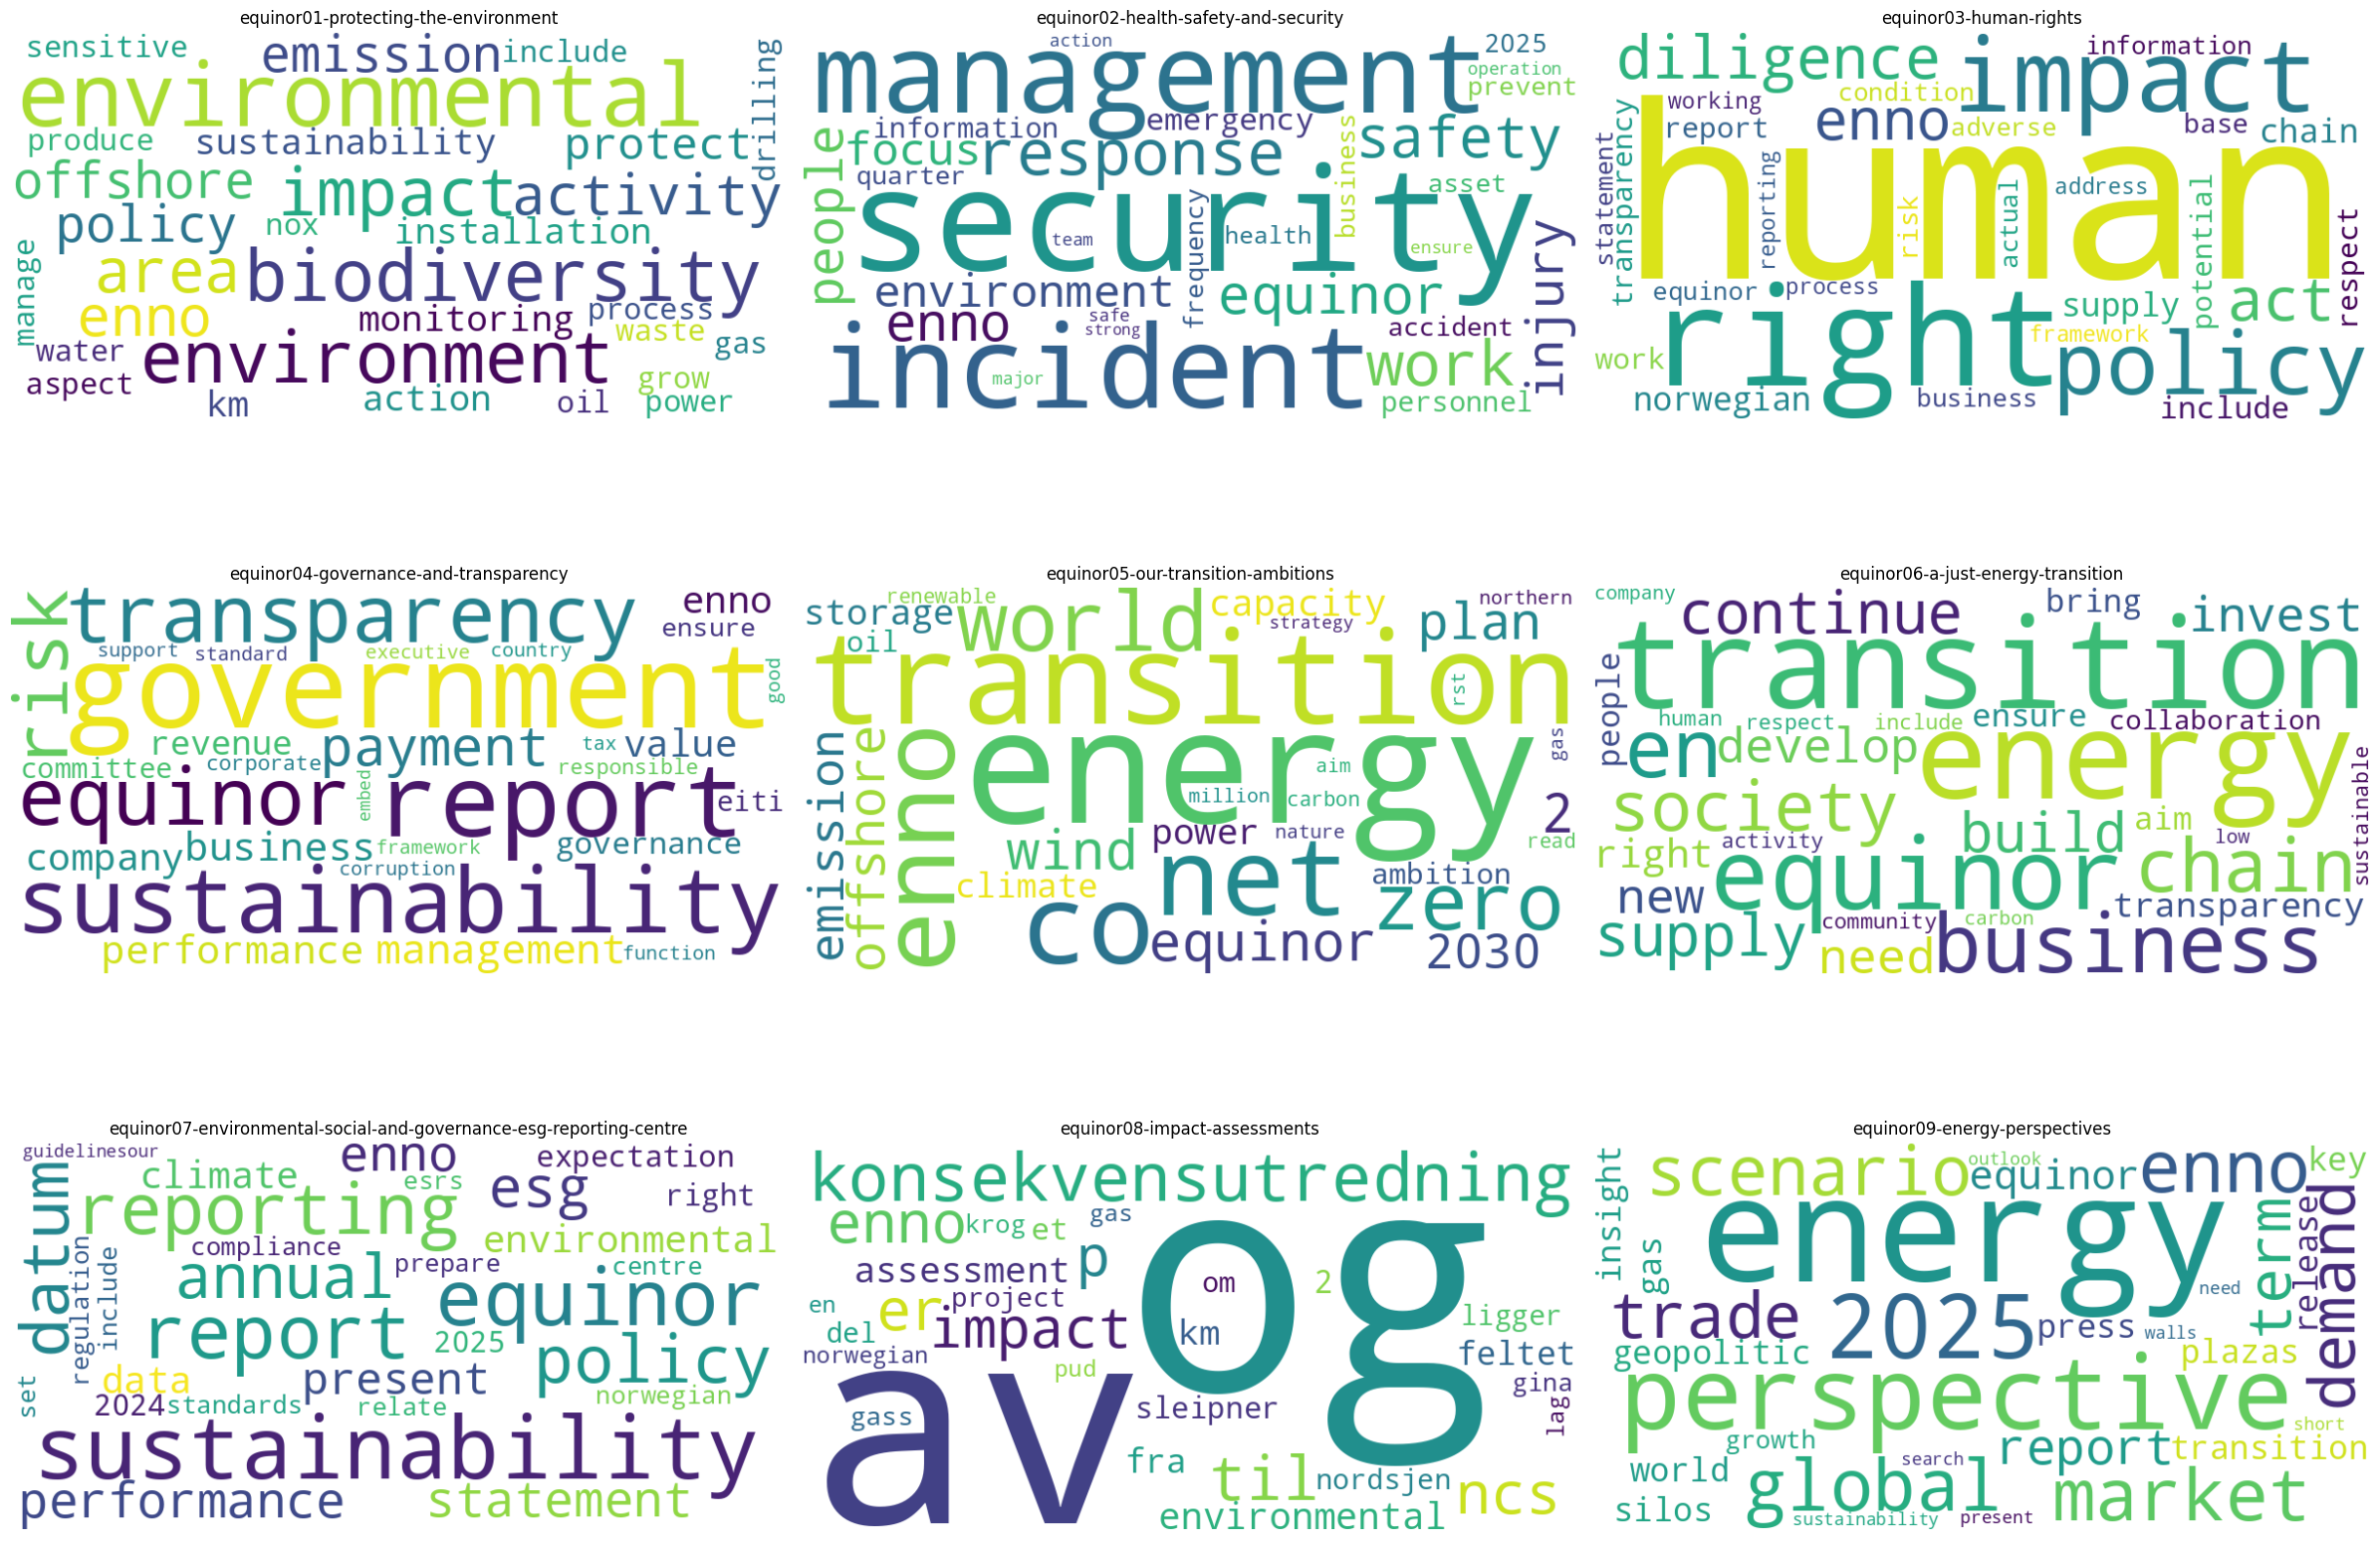

In [22]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math
import os
from collections import Counter

# Group tokens by text_id and concatenate the token_lemma for each text
# Ensure lemmas are lowercased for consistent word cloud generation
text_lemmas_by_doc = df_tokens.groupby('text_id')['token_lemma'].apply(lambda x: [lemma.lower() for lemma in x])

# Determine the number of unique texts (for subplots)
n_texts = len(text_lemmas_by_doc)
n_cols = 3
n_rows = math.ceil(n_texts / n_cols)

# Create a figure and a set of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 6))

# Flatten the axes array for easier iteration if there's more than one row/column
if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Ensure it's iterable even for a single subplot

for i, (text_id, lemmas_list) in enumerate(text_lemmas_by_doc.items()):
    if i < len(axes):
        ax = axes[i]

        # Count word frequencies and get the 30 most common
        word_frequencies = Counter(lemmas_list)
        top_30_words = dict(word_frequencies.most_common(30))

        # Generate a word cloud from frequencies
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(top_30_words)

        # Display the generated image:
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(text_id.replace('.txt', '')) # Clean up title
        ax.axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the figure to a high-resolution PNG file
save_directory = '/content/'
figure_filepath = os.path.join(save_directory, 'wordclouds_top30.png')
plt.savefig(figure_filepath, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filepath}")

plt.show()

In [23]:
import pandas as pd
import os

# Group by text_id, token_lemma, token_ner, token_pos and count occurrences
df_wordcloud = df_tokens.groupby(['text_id', 'token_lemma', 'token_ner', 'token_pos']).size().reset_index(name='token_frequency')

# Ensure token_lemma is lowercase (already done during df_tokens creation, but good for explicit confirmation)
df_wordcloud['token_lemma'] = df_wordcloud['token_lemma'].str.lower()

# Filter to include only the 30 most frequent tokens per text_id
df_wordcloud = df_wordcloud.groupby('text_id').apply(lambda x: x.nlargest(30, 'token_frequency')).reset_index(drop=True)

# Display the first few rows of the DataFrame
print("DataFrame df_wordcloud created successfully (first 5 rows):\n")
print(df_wordcloud.head())

# Save the DataFrame as a TSV file
save_directory = '/content/'
tsv_filepath_wordcloud = os.path.join(save_directory, 'df_wordcloud.tsv')
df_wordcloud.to_csv(tsv_filepath_wordcloud, sep='\t', index=False)
print(f"\nDataFrame df_wordcloud saved as TSV to: {tsv_filepath_wordcloud}")

DataFrame df_wordcloud created successfully (first 5 rows):

                                    text_id    token_lemma token_ner  \
0  equinor01-protecting-the-environment.txt  environmental             
1  equinor01-protecting-the-environment.txt   biodiversity             
2  equinor01-protecting-the-environment.txt    environment             
3  equinor01-protecting-the-environment.txt       activity             
4  equinor01-protecting-the-environment.txt           area             

  token_pos  token_frequency  
0       ADJ                9  
1      NOUN                7  
2      NOUN                6  
3      NOUN                5  
4      NOUN                5  

DataFrame df_wordcloud saved as TSV to: /content/df_wordcloud.tsv


/tmp/ipython-input-3788725263.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_wordcloud = df_wordcloud.groupby('text_id').apply(lambda x: x.nlargest(30, 'token_frequency')).reset_index(drop=True)


use df_wordcloud and create new df_esg by adding column esg_category with value "env" on all rows where text_id contains 01-03, with value "soc" on all rows where text_id contains 04-06, with value "gov" on all rows where text_id contains 07-09

In [24]:
import numpy as np
import os

# Create a copy of df_wordcloud to df_esg
df_esg = df_wordcloud.copy()

# Define conditions for ESG categories
conditions = [
    df_esg['text_id'].str.contains('01|02|03'),
    df_esg['text_id'].str.contains('04|05|06'),
    df_esg['text_id'].str.contains('07|08|09')
]

# Define corresponding choices for ESG categories
choices = ['env', 'soc', 'gov']

# Apply the conditions to create the 'esg_category' column
df_esg['esg_category'] = np.select(conditions, choices, default='other')

# Display the first few rows of the new DataFrame
print("DataFrame df_esg created successfully (first 5 rows):\n")
print(df_esg.head())

# Save the DataFrame as a TSV file
save_directory = '/content/'
tsv_filepath_esg = os.path.join(save_directory, 'df_esg.tsv')
df_esg.to_csv(tsv_filepath_esg, sep='\t', index=False)
print(f"\nDataFrame df_esg saved as TSV to: {tsv_filepath_esg}")

DataFrame df_esg created successfully (first 5 rows):

                                    text_id    token_lemma token_ner  \
0  equinor01-protecting-the-environment.txt  environmental             
1  equinor01-protecting-the-environment.txt   biodiversity             
2  equinor01-protecting-the-environment.txt    environment             
3  equinor01-protecting-the-environment.txt       activity             
4  equinor01-protecting-the-environment.txt           area             

  token_pos  token_frequency esg_category  
0       ADJ                9          env  
1      NOUN                7          env  
2      NOUN                6          env  
3      NOUN                5          env  
4      NOUN                5          env  

DataFrame df_esg saved as TSV to: /content/df_esg.tsv


/tmp/ipython-input-3729321731.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='token_frequency', y='token_lemma', data=top_tokens, ax=ax, palette='viridis')
/tmp/ipython-input-3729321731.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='token_frequency', y='token_lemma', data=top_tokens, ax=ax, palette='viridis')
/tmp/ipython-input-3729321731.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='token_frequency', y='token_lemma', data=top_tokens, ax=ax, palette='viridis')


Figure saved to: /content/esg_token_frequencies.png


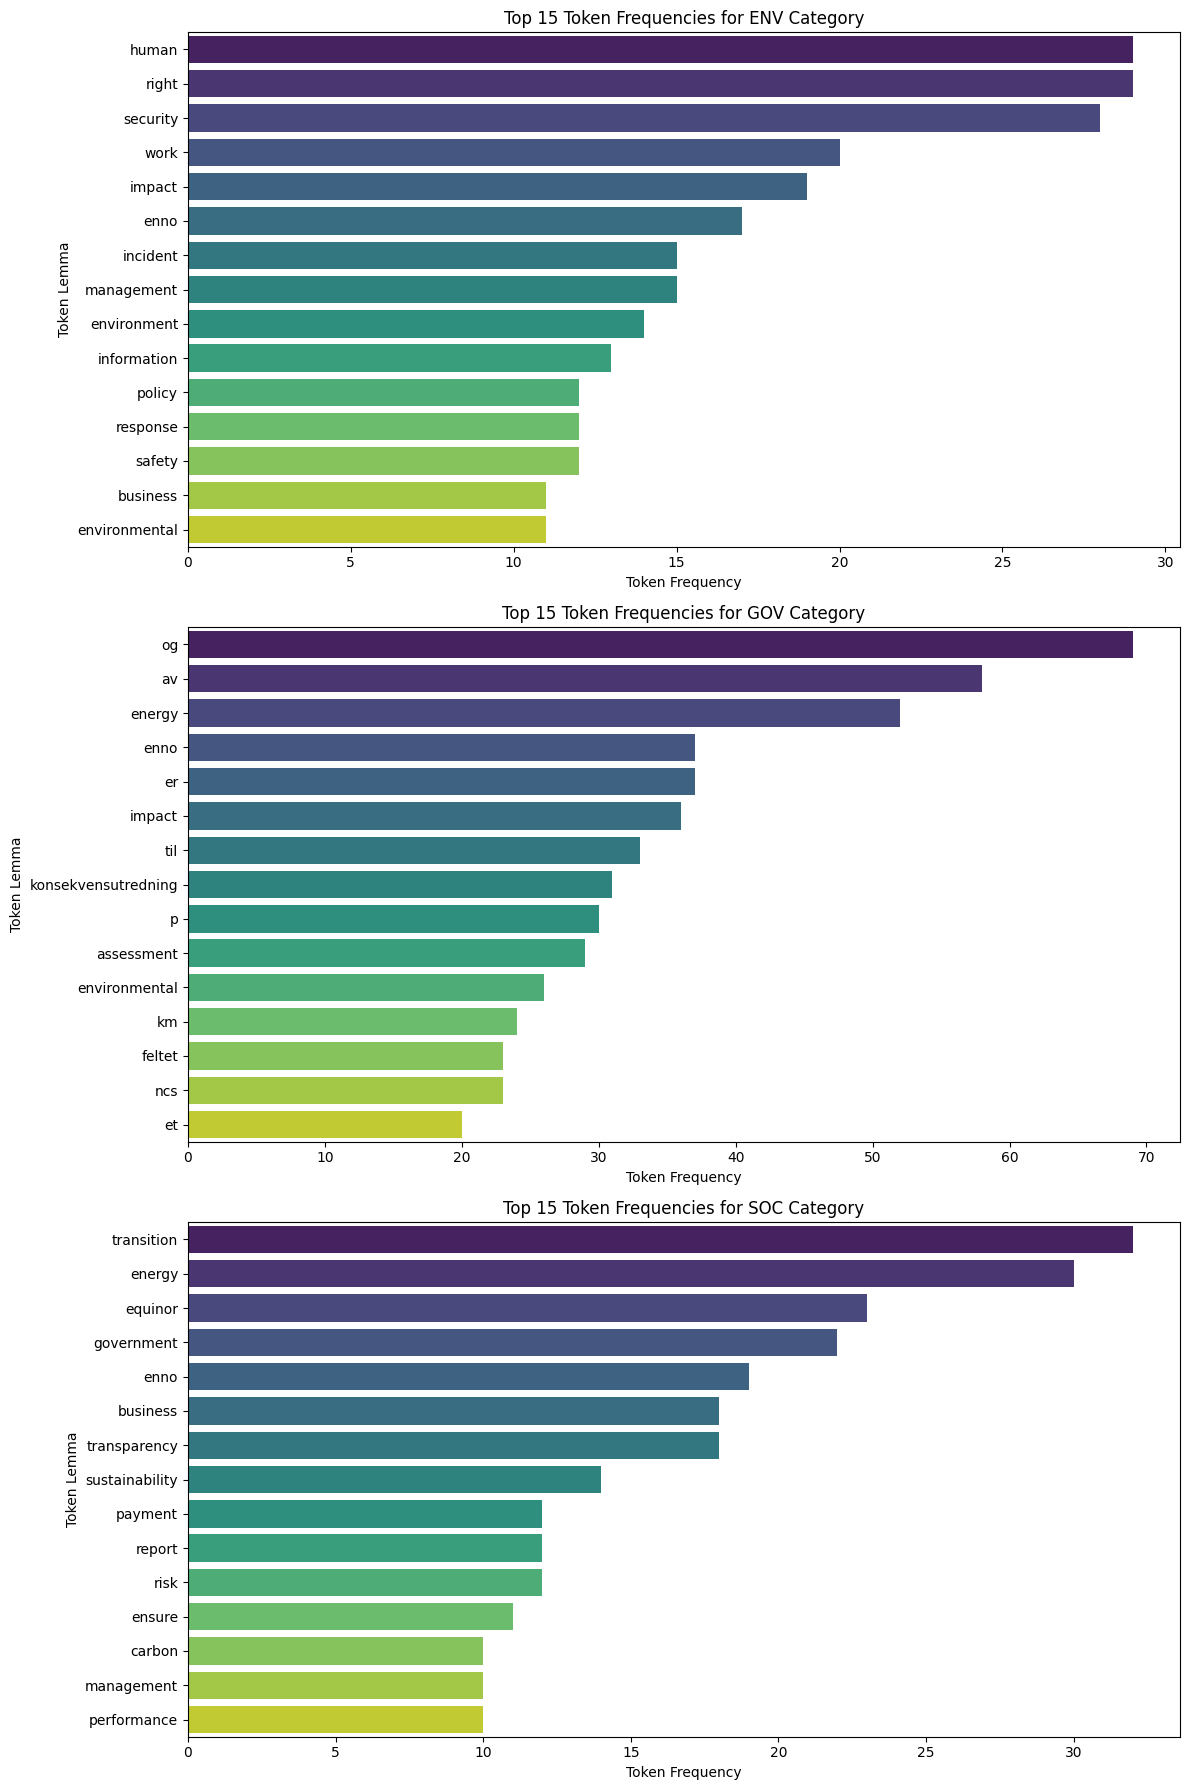

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by esg_category and token_lemma and sum the frequencies
esg_frequency_summary = df_esg.groupby(['esg_category', 'token_lemma'])['token_frequency'].sum().reset_index()

# Determine unique ESG categories
esg_categories = esg_frequency_summary['esg_category'].unique()
n_categories = len(esg_categories)

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(n_categories, 1, figsize=(12, 6 * n_categories))
axes = axes.flatten() if n_categories > 1 else [axes]

for i, category in enumerate(esg_categories):
    ax = axes[i]
    # Get the top 15 most frequent tokens for the current category
    top_tokens = esg_frequency_summary[esg_frequency_summary['esg_category'] == category].nlargest(15, 'token_frequency')

    sns.barplot(x='token_frequency', y='token_lemma', data=top_tokens, ax=ax, palette='viridis')
    ax.set_title(f'Top 15 Token Frequencies for {category.upper()} Category')
    ax.set_xlabel('Token Frequency')
    ax.set_ylabel('Token Lemma')

plt.tight_layout()

# Save the figure to a high-resolution PNG file
save_directory = '/content/'
figure_filepath_esg_freq = os.path.join(save_directory, 'esg_token_frequencies.png')
plt.savefig(figure_filepath_esg_freq, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filepath_esg_freq}")

plt.show()

# 3. Results

Present concise summary tables and intuitive visualizations that address each research question. Contrast expected outcomes with empirical patterns and highlight notable divergences. Ensure figures are readable in Colab, labeled clearly, and interpretable without additional code inspection.

# 4. Discussion

Interpret findings relative to theory and prior research, noting implications for sustainability communication practice. Propose realistic content improvements and hypotheses about optimizing cognitive communication effects. Acknowledge limitations (data size, methods) and outline concrete next steps for validation.